# Parte A — EDA de Pesquisa de Opinião (Cesop)

## Memória eleitoral, prioridades políticas e percepção sobre *fake news*

Este notebook é uma **Análise Exploratória de Dados (EDA)** de uma pesquisa de opinião de
abrangência nacional (instituto **Ipec**, acervo **Cesop**), com **2.000 respondentes** e 27
variáveis. O recorte temático investiga a relação entre **engajamento/memória eleitoral**
(eleições gerais de 2022) e atitudes políticas — prioridades de governo, vontade de participar
da vida política e posição sobre o combate às *fake news*.

### Pergunta condutora
> O **desengajamento eleitoral** (não lembrar em quem votou, não querer participar) se associa a
> um perfil distinto de **prioridades políticas** e de **postura sobre fake news**?

### Base externa correlacionada (requisito da Parte A)
Para além da própria pesquisa, cruzamos os dados com uma **base pública externa**: a
**abstenção oficial do TSE no 2º turno das eleições de 2022**, agregada por região
(Seção 10). Isso permite avaliar a *representatividade* da amostra frente ao comportamento
eleitoral real.

### Estrutura
1. Setup e carga dos dados
2. Dicionário de variáveis
3. Visão geral da amostra
4. Vontade de participar (P4)
5. Memória × vontade (P1×P4)
6. Prioridades × memória (P2×P1)
7. Intensidade de opinião sobre fake news (P3×P1)
8. Postura sobre fake news × vontade (P3×P4)
9. Regulação vs. punição (análise central)
10. **Base externa — abstenção TSE 2022**
11. Conclusões

> **Fontes:** microdados da pesquisa (Ipec/Cesop, `.sav`) · abstenção por UF: TSE, 2º turno 2022.

---

## 1. Setup e carga dos dados

Importações, paleta visual padronizada, download do arquivo `.sav` e criação das variáveis auxiliares (perfil de fake news e indicadores de memória eleitoral).

In [1]:
# @title Setup global

!pip install pyreadstat gdown --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyreadstat, gdown, warnings, os
warnings.filterwarnings('ignore')

# Tema visual único para todo o notebook
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130})

# Paleta padrão do trabalho
COR_LEMBRA   = '#2E7D32'   # verde escuro
COR_NLEMBRA  = '#C62828'   # vermelho escuro
COR_MUITA    = '#1565C0'   # azul escuro
COR_ALGUMA   = '#64B5F6'   # azul claro
COR_NENHUMA  = '#EF5350'   # vermelho
COR_REG      = '#1976D2'   # azul — regulação
COR_PUN      = '#E64A19'   # laranja/vermelho — punição
COR_EQ       = '#F9A825'   # amarelo — equilibrado

# Carregamento dos dados
FILE_ID = '1Z8pS-1WuVgwtpVE7MW5hqg6HeItnE3t6'
OUT     = 'downloaded_data.sav'
gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUT, quiet=False)
df, meta = pyreadstat.read_sav(OUT)

print(f"✅ Dados carregados: {df.shape[0]} respondentes · {df.shape[1]} variáveis")

# Mapa de rótulos reutilizável
P1_MAP = {1.0: 'Sim', 2.0: 'Não', 3.0: 'Não votou', 99.0: 'Não respondeu'}
P4_MAP = {1.0: 'Muita vontade', 2.0: 'Alguma vontade',
          3.0: 'Nenhuma vontade', 99.0: 'Não respondeu'}
P2_CURTO = {
    1.0: 'Reduzir desigualdades',   2.0: 'Combater preconceito',
    3.0: 'Impostos grandes fortunas', 4.0: 'Gerar empregos',
    5.0: 'Mudanças climáticas',     6.0: 'Energias renováveis',
    7.0: 'Valores da família',      8.0: 'Igualdade de gênero',
    9.0: 'Qualidade da saúde',     10.0: 'Qualidade da educação',
   11.0: 'Reduzir violência',      12.0: 'Participação política',
}
P3_CURTO = {
    1.0: 'Reg. plataformas digitais',  2.0: 'Punição: empresas tech',
    3.0: 'Reg. usuários',              4.0: 'Punição: usuários',
    5.0: 'Reg. políticos',             6.0: 'Punição: políticos',
}

# Colunas P3
P3_COLS = ['P3_1','P3_2','P3_3','P3_4','P3_5','P3_6']

# Coluna auxiliar: perfil de postura sobre fake news (regulação vs punição)
REG_VALS = [1.0, 3.0, 5.0]
PUN_VALS = [2.0, 4.0, 6.0]

def perfil_fakenews(row):
    respostas = [row[c] for c in P3_COLS if not pd.isna(row[c]) and row[c] != 99.0]
    n_reg = sum(1 for v in respostas if v in REG_VALS)
    n_pun = sum(1 for v in respostas if v in PUN_VALS)
    if not respostas:
        return 'Não respondeu'
    if n_reg > n_pun:   return 'Mais regulação'
    if n_pun > n_reg:   return 'Mais punição'
    return 'Equilibrado'

df['perfil_fn'] = df.apply(perfil_fakenews, axis=1)

# Coluna auxiliar: memória eleitoral geral (lembra de pelo menos 1 voto)
df['lembra_algum']  = ((df['P1A']==1)|(df['P1B']==1)|(df['P1C']==1))
df['lembra_todos']  = ((df['P1A']==1)&(df['P1B']==1)&(df['P1C']==1))
df['nlembra_nenhum']= ((df['P1A']==2)&(df['P1B']==2)&(df['P1C']==2))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 17.6 MB/s eta 0:00:00


Downloading...
From: https://drive.google.com/uc?id=1Z8pS-1WuVgwtpVE7MW5hqg6HeItnE3t6
To: /content/downloaded_data.sav
100%|██████████| 95.1k/95.1k [00:00<00:00, 30.5MB/s]

✅ Dados carregados: 2000 respondentes · 27 variáveis


## 2. Dicionário de variáveis

Tabela de tradução dos códigos numéricos do `.sav` para os rótulos originais do questionário (perguntas P1 a P4).

In [3]:
# @title Tabela de tradução
import pandas as pd

traducao = pd.DataFrame([
    # P1A
    ["P1A", "Você se lembra em quem votou para deputado(a) estadual nas eleições gerais de 2022?", 1, "Sim"],
    ["P1A", "Você se lembra em quem votou para deputado(a) estadual nas eleições gerais de 2022?", 2, "Não"],
    ["P1A", "Você se lembra em quem votou para deputado(a) estadual nas eleições gerais de 2022?", 3, "Não votou em 2022 (Esp.)"],
    ["P1A", "Você se lembra em quem votou para deputado(a) estadual nas eleições gerais de 2022?", 99, "Não respondeu"],

    # P1B
    ["P1B", "Você se lembra em quem votou para deputado(a) federal nas eleições gerais de 2022?", 1, "Sim"],
    ["P1B", "Você se lembra em quem votou para deputado(a) federal nas eleições gerais de 2022?", 2, "Não"],
    ["P1B", "Você se lembra em quem votou para deputado(a) federal nas eleições gerais de 2022?", 3, "Não votou em 2022 (Esp.)"],
    ["P1B", "Você se lembra em quem votou para deputado(a) federal nas eleições gerais de 2022?", 99, "Não respondeu"],

    # P1C
    ["P1C", "Você se lembra em quem votou para senador(a) nas eleições gerais de 2022?", 1, "Sim"],
    ["P1C", "Você se lembra em quem votou para senador(a) nas eleições gerais de 2022?", 2, "Não"],
    ["P1C", "Você se lembra em quem votou para senador(a) nas eleições gerais de 2022?", 3, "Não votou em 2022 (Esp.)"],
    ["P1C", "Você se lembra em quem votou para senador(a) nas eleições gerais de 2022?", 99, "Não respondeu"],

    # P2_1
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 1, "Reduzir as desigualdades sociais"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 2, "Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 3, "Aumentar os impostos de grandes fortunas (ou dos mais ricos)"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 4, "Incentivar a geração de empregos"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 5, "Combater as mudanças climáticas/desmatamento"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 6, "Ampliar o uso de energias renováveis"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 7, "Preservar os valores ligados à família"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 8, "Defender a igualdade entre homens e mulheres"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 9, "Melhorar a qualidade da saúde"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 10, "Melhorar a qualidade da educação"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 11, "Reduzir a violência"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 12, "Ampliar os espaços de participação política da população"],
    ["P2_1", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (1º lugar)", 99, "Não sabe/ Não respondeu"],

    # P2_2
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 1, "Reduzir as desigualdades sociais"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 2, "Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 3, "Aumentar os impostos de grandes fortunas (ou dos mais ricos)"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 4, "Incentivar a geração de empregos"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 5, "Combater as mudanças climáticas/desmatamento"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 6, "Ampliar o uso de energias renováveis"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 7, "Preservar os valores ligados à família"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 8, "Defender a igualdade entre homens e mulheres"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 9, "Melhorar a qualidade da saúde"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 10, "Melhorar a qualidade da educação"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 11, "Reduzir a violência"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 12, "Ampliar os espaços de participação política da população"],
    ["P2_2", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (2º lugar)", 99, "Não sabe/ Não respondeu"],

    # P2_3
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 1, "Reduzir as desigualdades sociais"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 2, "Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 3, "Aumentar os impostos de grandes fortunas (ou dos mais ricos)"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 4, "Incentivar a geração de empregos"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 5, "Combater as mudanças climáticas/desmatamento"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 6, "Ampliar o uso de energias renováveis"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 7, "Preservar os valores ligados à família"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 8, "Defender a igualdade entre homens e mulheres"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 9, "Melhorar a qualidade da saúde"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 10, "Melhorar a qualidade da educação"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 11, "Reduzir a violência"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 12, "Ampliar os espaços de participação política da população"],
    ["P2_3", "Qual destas propostas você acha que deveria ser prioridade de um(a) político(a)? (3º lugar)", 99, "Não sabe/ Não respondeu"],

    # P3_1
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 3, "Ampliar regulamentação para usuários"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 4, "Responsabilizar e punir usuários"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 5, "Ampliar regulamentação para políticos"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 6, "Responsabilizar e punir políticos"],
    ["P3_1", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?", 99, "Não sabe/ Não respondeu"],

    # P3_2
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 3, "Ampliar regulamentação para usuários"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 4, "Responsabilizar e punir usuários"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 5, "Ampliar regulamentação para políticos"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 6, "Responsabilizar e punir políticos"],
    ["P3_2", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Mais alguma?", 99, "Não sabe/ Não respondeu"],

    # P3_3
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 3, "Ampliar regulamentação para usuários"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 4, "Responsabilizar e punir usuários"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 5, "Ampliar regulamentação para políticos"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 6, "Responsabilizar e punir políticos"],
    ["P3_3", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 99, "Não sabe/ Não respondeu"],

    # P3_4
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 3, "Ampliar regulamentação para usuários"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 4, "Responsabilizar e punir usuários"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 5, "Ampliar regulamentação para políticos"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 6, "Responsabilizar e punir políticos"],
    ["P3_4", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 99, "Não sabe/ Não respondeu"],

    # P3_5
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 3, "Ampliar regulamentação para usuários"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 4, "Responsabilizar e punir usuários"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 5, "Ampliar regulamentação para políticos"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 6, "Responsabilizar e punir políticos"],
    ["P3_5", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 99, "Não sabe/ Não respondeu"],

    # P3_6
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 1, "Ampliar regulamentação para plataformas digitais"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 2, "Responsabilizar e punir empresas de tecnologia"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 3, "Ampliar regulamentação para usuários"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 4, "Responsabilizar e punir usuários"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 5, "Ampliar regulamentação para políticos"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 6, "Responsabilizar e punir políticos"],
    ["P3_6", "Algumas pessoas dizem que a divulgação de fake news - notícias ou conteúdos falsos podem prejudicar a democracia. Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news? Alguma outra?", 99, "Não sabe/ Não respondeu"],

    # P4
    ["P4", "Você diria que tem muita vontade, alguma vontade ou nenhuma vontade de participar da vida política na sua cidade?", 1, "Muita vontade"],
    ["P4", "Você diria que tem muita vontade, alguma vontade ou nenhuma vontade de participar da vida política na sua cidade?", 2, "Alguma vontade"],
    ["P4", "Você diria que tem muita vontade, alguma vontade ou nenhuma vontade de participar da vida política na sua cidade?", 3, "Nenhuma vontade"],
    ["P4", "Você diria que tem muita vontade, alguma vontade ou nenhuma vontade de participar da vida política na sua cidade?", 99, "Não sabe/ Não respondeu"],

], columns=["questao", "pergunta", "valor", "resposta"])

traducao


,questao,pergunta,valor,resposta
0,P1A,Você se lembra em quem votou para deputado(a) ...,1,Sim
1,P1A,Você se lembra em quem votou para deputado(a) ...,2,Não
2,P1A,Você se lembra em quem votou para deputado(a) ...,3,Não votou em 2022 (Esp.)
3,P1A,Você se lembra em quem votou para deputado(a) ...,99,Não respondeu
4,P1B,Você se lembra em quem votou para deputado(a) ...,1,Sim
...,...,...,...,...
92,P3_6,Algumas pessoas dizem que a divulgação de fake...,99,Não sabe/ Não respondeu
93,P4,"Você diria que tem muita vontade, alguma vonta...",1,Muita vontade
94,P4,"Você diria que tem muita vontade, alguma vonta...",2,Alguma vontade
95,P4,"Você diria que tem muita vontade, alguma vonta...",3,Nenhuma vontade


## 3. Visão geral da amostra (EDA univariado)

Tamanho da amostra, % de valores ausentes e distribuições brutas das variáveis-chave.

In [4]:
# @title EDA — Visão geral da amostra

print("=" * 55)
print(f"Total de respondentes : {len(df)}")
print(f"Total de variáveis    : {df.shape[1]}")

cols = ['P1A','P1B','P1C','P2_1','P2_2','P2_3',
        'P3_1','P3_2','P3_3','P3_4','P3_5','P3_6','P4']
print("\n--- % de valores ausentes nas variáveis analisadas ---")
print(df[cols].isnull().mean().mul(100).round(1).to_string())

print("\n--- Distribuição de P4 (vontade de participar na política) ---")
print(df['P4'].map(P4_MAP).value_counts().to_string())

for col, cargo in zip(['P1A','P1B','P1C'],['Dep. Estadual','Dep. Federal','Senador']):
    print(f"\n--- {col} — {cargo} ---")
    print(df[col].map(P1_MAP).value_counts().to_string())

Total de respondentes : 2000
Total de variáveis    : 31

--- % de valores ausentes nas variáveis analisadas ---
P1A      0.0
P1B      0.0
P1C      0.0
P2_1     0.0
P2_2     5.9
P2_3    10.4
P3_1     0.0
P3_2    59.1
P3_3    84.8
P3_4    95.6
P3_5    97.2
P3_6    98.0
P4       0.0

--- Distribuição de P4 (vontade de participar na política) ---
P4
Nenhuma vontade    1559
Alguma vontade      264
Muita vontade       169
Não respondeu         8

--- P1A — Dep. Estadual ---
P1A
Não              1285
Sim               593
Não votou         110
Não respondeu      12

--- P1B — Dep. Federal ---
P1B
Não              1293
Sim               586
Não votou         111
Não respondeu      10

--- P1C — Senador ---
P1C
Não              1290
Sim               588
Não votou         110
Não respondeu      12


**Leitura.**

- **Memória eleitoral baixa.** Apenas **~30%** declaram lembrar em quem votaram em cada cargo
  (Sim ≈ 590/2.000); cerca de **64%** não lembram. Ou seja, a maioria não retém a própria
  escolha eleitoral de 2022.
- **Desinteresse político alto.** Em P4, **78%** dizem ter *nenhuma vontade* de participar da
  vida política local; só **8,5%** têm muita vontade.


## 4. Vontade de participar da política (P4)

Distribuição da disposição de participar da vida política na cidade.

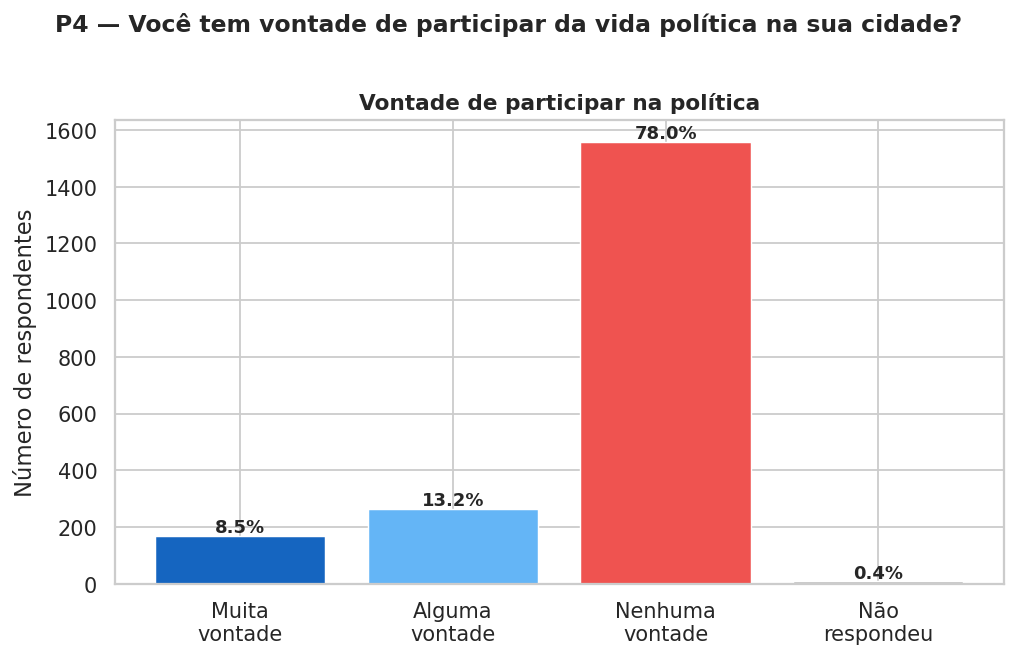

Nenhuma vontade: 1559 respondentes (78.0% da amostra)


In [5]:
# @title Distribuição geral: vontade de participar na política

ordem_p4   = ['Muita\nvontade', 'Alguma\nvontade', 'Nenhuma\nvontade', 'Não\nrespondeu']
p4_br_map  = {1.0:'Muita\nvontade', 2.0:'Alguma\nvontade',
              3.0:'Nenhuma\nvontade', 99.0:'Não\nrespondeu'}
cores_p4   = [COR_MUITA, COR_ALGUMA, COR_NENHUMA, '#BDBDBD']

p4_data = df['P4'].map(p4_br_map).value_counts().reindex(ordem_p4).dropna()

fig, ax = plt.subplots(figsize=(8, 5)) # Changed from (1, 2) subplots to a single one

# Barras
bars = ax.bar(p4_data.index, p4_data.values, color=cores_p4,
                   edgecolor='white', linewidth=0.8)
for bar in bars:
    h   = bar.get_height()
    pct = h / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 12,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Vontade de participar na política', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de respondentes')
ax.set_xlabel('')

plt.suptitle('P4 — Você tem vontade de participar da vida política na sua cidade?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('P4_distribuicao.png', bbox_inches='tight')
plt.show()

# Insight textual
nenhuma = p4_data.get('Nenhuma\nvontade', 0)
pct_nenhuma = nenhuma / len(df) * 100
print(f'Nenhuma vontade: {int(nenhuma)} respondentes ({pct_nenhuma:.1f}% da amostra)')


**Leitura.** O desinteresse é massivo e transversal: ~4 em cada 5 respondentes não têm vontade alguma de participar. Esse desengajamento é o pano de fundo dos cruzamentos seguintes.

## 5. Memória eleitoral × vontade política (P1 × P4)

% que lembra em quem votou, por nível de vontade de participar.

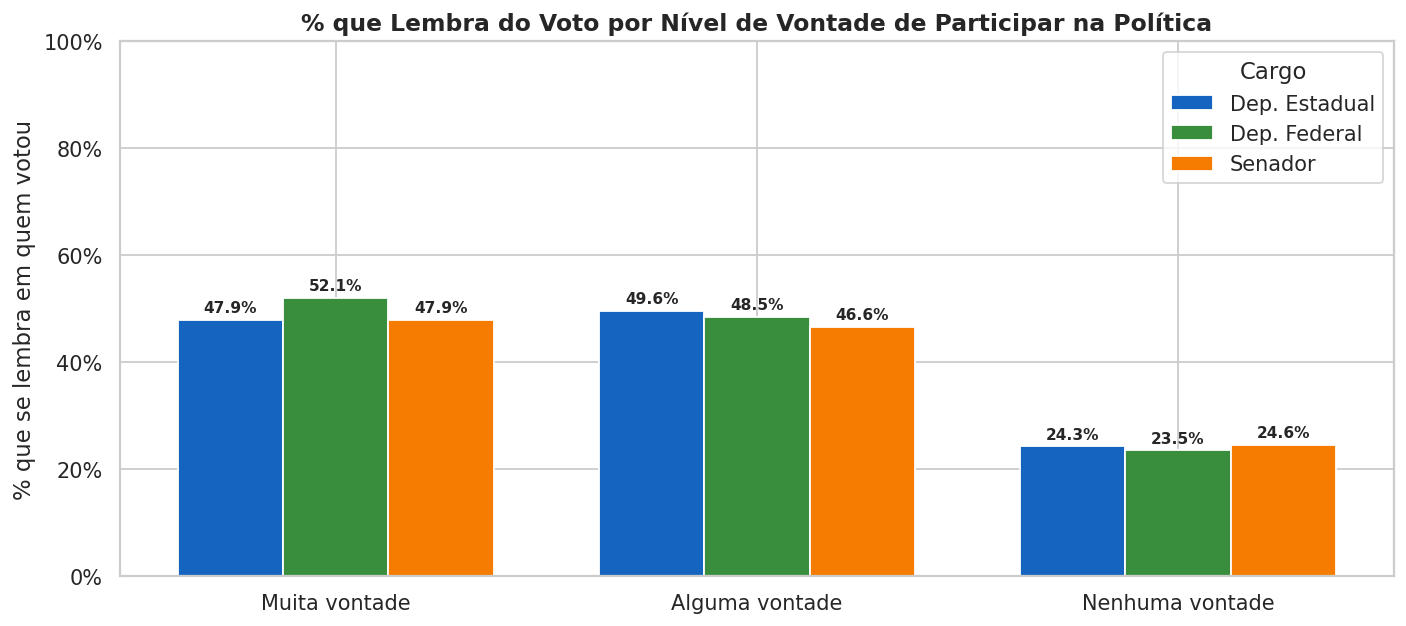

In [6]:
# @title P4 × P1 — % que lembra do voto por nível de vontade política

niveis   = ['Muita vontade', 'Alguma vontade', 'Nenhuma vontade']
p4_num   = {1.0:'Muita vontade', 2.0:'Alguma vontade', 3.0:'Nenhuma vontade'}
cargos   = {'P1A':'Dep. Estadual', 'P1B':'Dep. Federal', 'P1C':'Senador'}
cores_c  = [COR_MUITA, '#388E3C', '#F57C00']

resultado = []
for p4_val, p4_nome in p4_num.items():
    df_g = df[df['P4'] == p4_val]
    n    = len(df_g)
    for col, cargo in cargos.items():
        lembra = (df_g[col] == 1.0).sum()
        resultado.append({'Vontade': p4_nome, 'Cargo': cargo,
                          'Pct': lembra/n*100 if n>0 else 0, 'N': n})

df_r = pd.DataFrame(resultado)

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(niveis))
width = 0.25

for i, (cargo, cor) in enumerate(zip(cargos.values(), cores_c)):
    vals = [df_r[(df_r['Vontade']==n)&(df_r['Cargo']==cargo)]['Pct'].values[0]
            for n in niveis]
    bars = ax.bar(x + i*width, vals, width, label=cargo, color=cor, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(niveis)
ax.set_ylabel('% que se lembra em quem votou')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('% que Lembra do Voto por Nível de Vontade de Participar na Política',
             fontsize=13, fontweight='bold')
ax.legend(title='Cargo')
plt.tight_layout()
plt.savefig('P4xP1_memoria.png', bbox_inches='tight')
plt.show()

**Leitura — gradiente claro.** A memória do voto cresce com o engajamento:

| Vontade de participar | % que lembra de ≥1 voto |
|---|---|
| Muita | **59,2%** |
| Alguma | **57,2%** |
| Nenhuma | **31,9%** |

Quem tem muita/alguma vontade lembra do voto **quase o dobro** de quem não tem nenhuma. Memória
e interesse político caminham juntos e desengajamento é também *amnésia eleitoral*.

## 6. Prioridades políticas × memória (P2 × P1)

Comparação das prioridades de governo (P2_1+P2_2+P2_3) entre quem lembra e quem não lembra do voto.

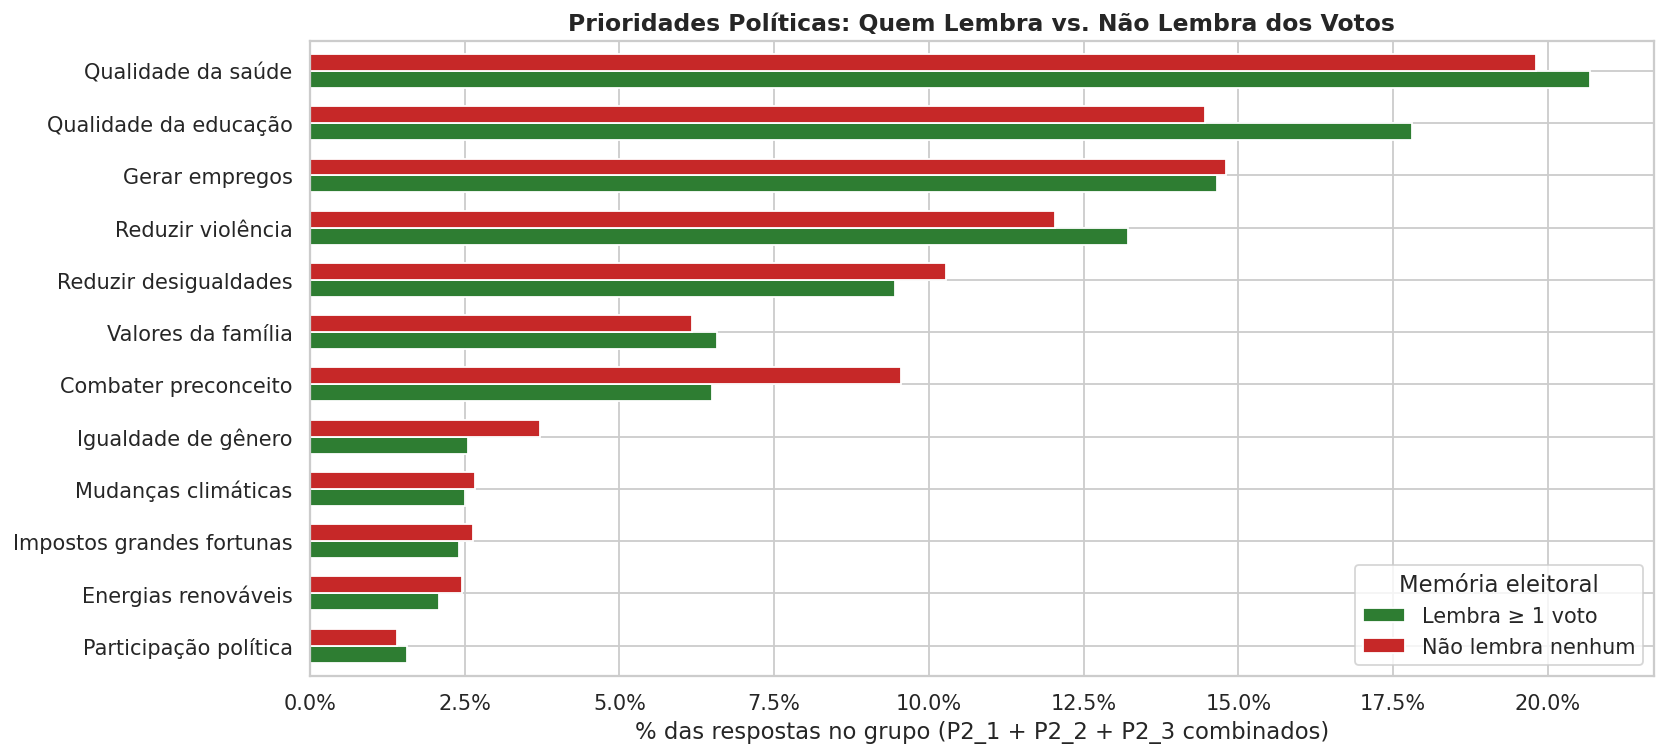

In [7]:
# @title P1 × P2: Prioridades políticas × Memória eleitoral

grupos_p1 = {
    'Lembra ≥ 1 voto' : df[df['lembra_algum']],
    'Não lembra nenhum': df[df['nlembra_nenhum']],
}

resultado_p2 = []
for grupo, df_g in grupos_p1.items():
    for col in ['P2_1','P2_2','P2_3']:
        for val, cnt in df_g[col].value_counts().items():
            if val in P2_CURTO:
                resultado_p2.append({'Grupo': grupo,
                                     'Prioridade': P2_CURTO[val],
                                     'Contagem': cnt})

df_p2 = (pd.DataFrame(resultado_p2)
           .groupby(['Grupo','Prioridade'])['Contagem'].sum()
           .reset_index())
df_p2['Pct'] = (df_p2['Contagem']
                / df_p2.groupby('Grupo')['Contagem'].transform('sum') * 100)

pivot_p2 = (df_p2.pivot(index='Prioridade', columns='Grupo', values='Pct')
              .fillna(0)
              [['Lembra ≥ 1 voto','Não lembra nenhum']])
pivot_p2 = pivot_p2.sort_values('Lembra ≥ 1 voto', ascending=True)

# Diferença absoluta entre grupos (destacar divergências)
pivot_p2['diff'] = abs(pivot_p2['Lembra ≥ 1 voto'] - pivot_p2['Não lembra nenhum'])

fig, ax = plt.subplots(figsize=(13, 6))
pivot_p2[['Lembra ≥ 1 voto','Não lembra nenhum']].plot(
    kind='barh', ax=ax,
    color=[COR_LEMBRA, COR_NLEMBRA],
    edgecolor='white', width=0.65)

ax.set_title('Prioridades Políticas: Quem Lembra vs. Não Lembra dos Votos',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% das respostas no grupo (P2_1 + P2_2 + P2_3 combinados)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Memória eleitoral')
plt.tight_layout()
plt.savefig('P1xP2_prioridades.png', bbox_inches='tight')
plt.show()

**Leitura.** As prioridades **materiais** (saúde, educação, empregos, redução da violência) dominam nos dois grupos, a agenda básica é consensual. As maiores divergências aparecem em pautas mais *identitárias/abstratas*: quem lembra do voto tende a pontuar mais temas como participação política e meio ambiente, enquanto o grupo desengajado se concentra ainda mais nas urgências do dia a dia.

## 7. Intensidade de opinião sobre fake news (P3 × P1)

Número médio de medidas de combate à desinformação citadas, por grupo de memória eleitoral.

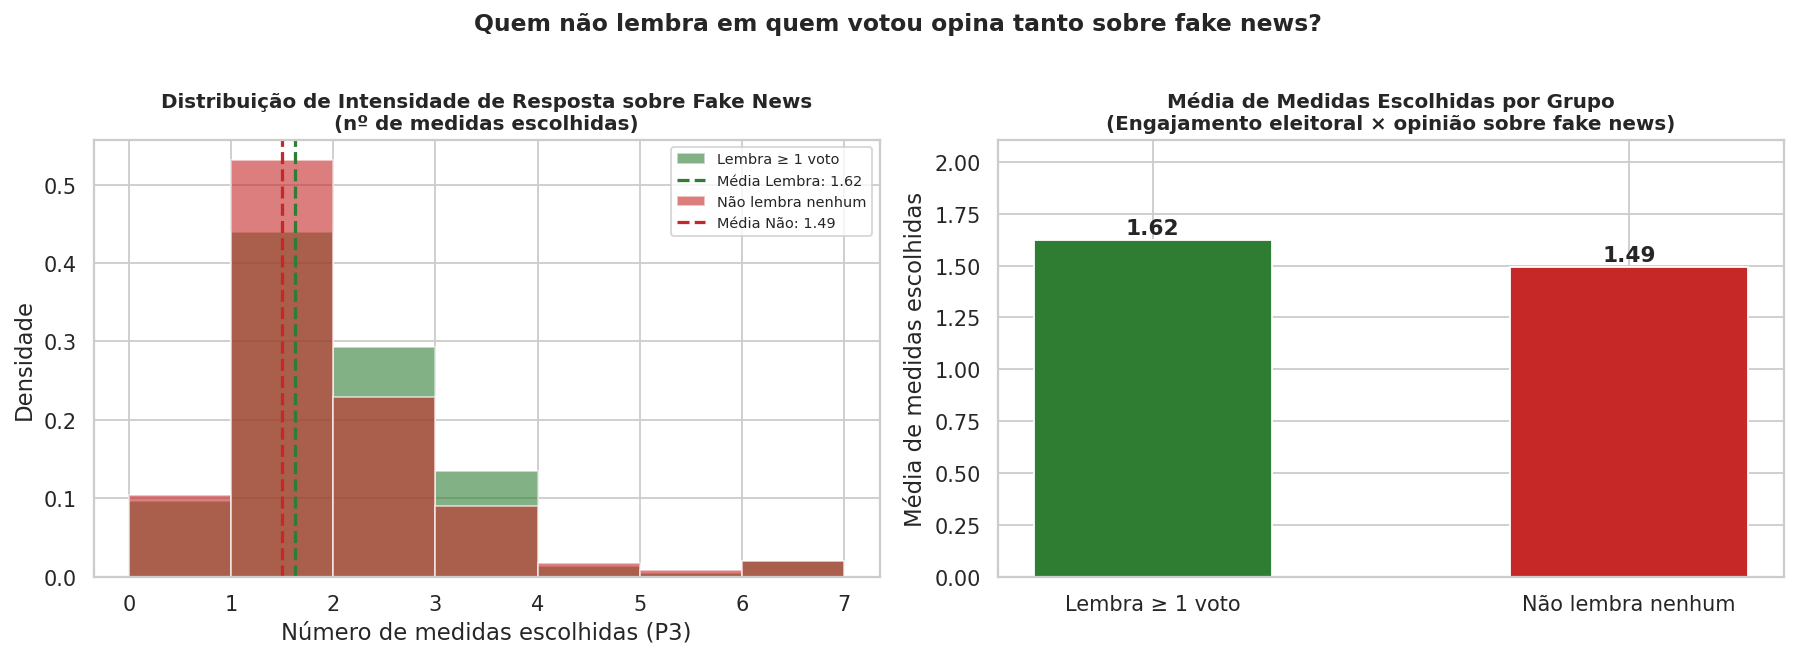

In [8]:
# @title P1 × Intensidade de resposta no P3

df['n_respostas_p3'] = df[P3_COLS].apply(
    lambda row: sum(1 for v in row if not pd.isna(v) and v != 99.0), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: distribuição de intensidade por grupo de memória ---
grupos_plot = {
    'Lembra ≥ 1 voto' : df[df['lembra_algum']]['n_respostas_p3'],
    'Não lembra nenhum': df[df['nlembra_nenhum']]['n_respostas_p3'],
}

medias = {}
for grupo, serie in grupos_plot.items():
    medias[grupo] = serie.mean()

# Histograma sobreposto
for (grupo, serie), cor in zip(grupos_plot.items(), [COR_LEMBRA, COR_NLEMBRA]):
    axes[0].hist(serie, bins=range(0, 8), alpha=0.6, label=grupo,
                 color=cor, edgecolor='white', density=True)
    axes[0].axvline(serie.mean(), color=cor, linestyle='--', linewidth=1.8,
                    label=f'Média {grupo.split()[0]}: {serie.mean():.2f}')

axes[0].set_title('Distribuição de Intensidade de Resposta sobre Fake News\n(nº de medidas escolhidas)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Número de medidas escolhidas (P3)')
axes[0].set_ylabel('Densidade')
axes[0].legend(fontsize=8)

# --- Subplot 2: média de respostas por grupo de memória (barras simples) ---
bar_labels = list(medias.keys())
bar_vals   = list(medias.values())
cores_bar  = [COR_LEMBRA, COR_NLEMBRA]
bars = axes[1].bar(bar_labels, bar_vals, color=cores_bar, edgecolor='white', width=0.5)
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.03,
                 f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Média de Medidas Escolhidas por Grupo\n(Engajamento eleitoral × opinião sobre fake news)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Média de medidas escolhidas')
axes[1].set_ylim(0, max(bar_vals)*1.3)
axes[1].set_xlabel('')

plt.suptitle('Quem não lembra em quem votou opina tanto sobre fake news?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('P1xP3_intensidade.png', bbox_inches='tight')
plt.show()

**Leitura.** Mesmo quem **não lembra** em quem votou opina sobre *fake news* — a intensidade média de respostas em P3 é parecida entre os grupos. Ter opinião sobre desinformação **não depende** de engajamento eleitoral: é um tema de adesão ampla, desacoplado da memória de voto.

## 8. Postura sobre fake news × vontade política (P3 × P4)

Distribuição das medidas (regulação vs. punição) por nível de vontade de participar.

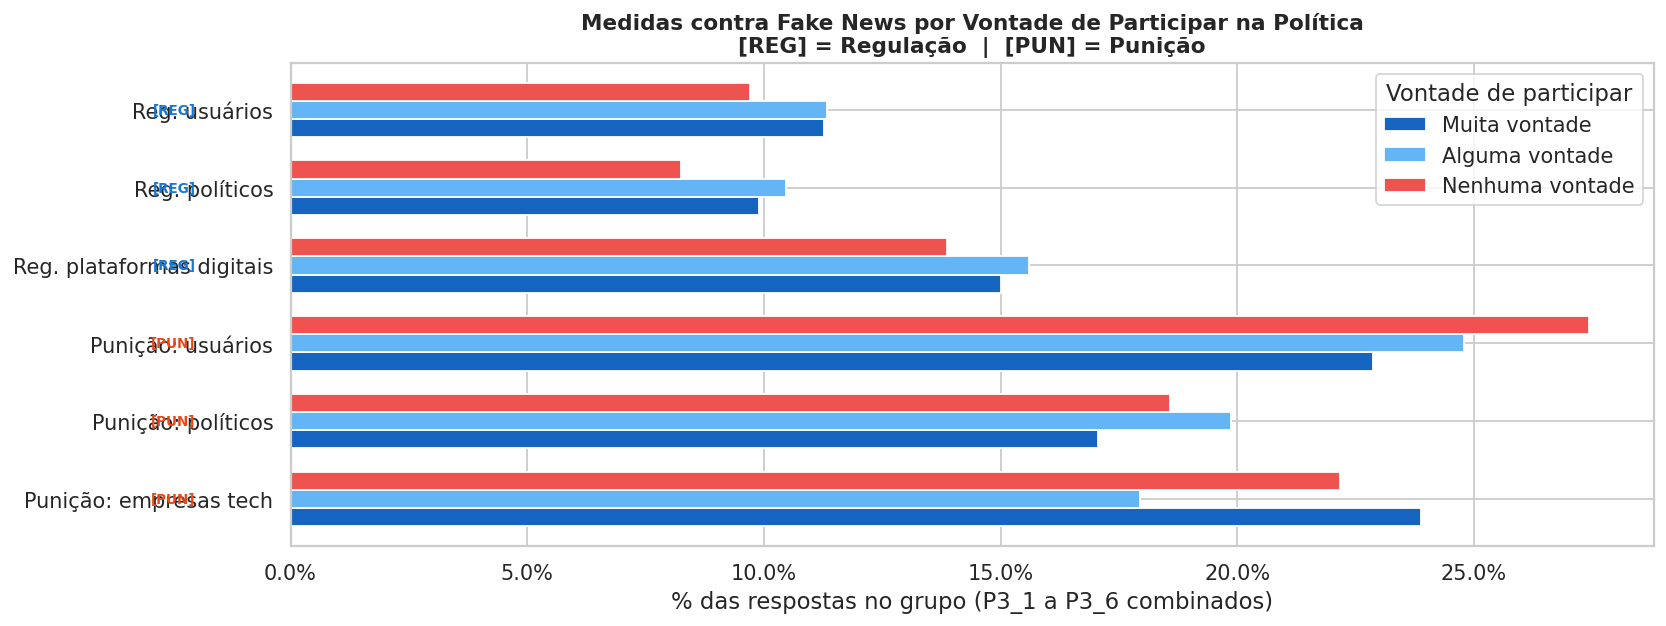

In [9]:
# @title P4 × P3: Vontade política × Postura sobre fake news


p4_grupos = {
    'Muita vontade'  : df[df['P4']==1.0],
    'Alguma vontade' : df[df['P4']==2.0],
    'Nenhuma vontade': df[df['P4']==3.0],
}

resultado_p4p3 = []
for grupo, df_g in p4_grupos.items():
    for col in P3_COLS:
        for val, cnt in df_g[col].value_counts().items():
            if val in P3_CURTO:
                resultado_p4p3.append({'Grupo': grupo,
                                       'Medida': P3_CURTO[val],
                                       'Contagem': cnt})

df_p4p3 = (pd.DataFrame(resultado_p4p3)
             .groupby(['Grupo','Medida'])['Contagem'].sum()
             .reset_index())
df_p4p3['Pct'] = (df_p4p3['Contagem']
                  / df_p4p3.groupby('Grupo')['Contagem'].transform('sum') * 100)

pivot_p4p3 = (df_p4p3.pivot(index='Medida', columns='Grupo', values='Pct')
                .fillna(0)
                [['Muita vontade','Alguma vontade','Nenhuma vontade']])

fig, ax = plt.subplots(figsize=(13, 5))
pivot_p4p3.plot(kind='barh', ax=ax,
                color=[COR_MUITA, COR_ALGUMA, COR_NENHUMA],
                edgecolor='white', width=0.7)

# Linha vertical separando regulação de punição visualmente (não há como separar linhas)
# Adiciona anotações de tipo
for label in ax.get_yticklabels():
    t = label.get_text()
    tipo = 'REG' if t.startswith('Reg.') else 'PUN'
    cor  = COR_REG if tipo=='REG' else COR_PUN
    ax.annotate(f'[{tipo}]', xy=(0, label.get_position()[1]),
                xycoords=('data','data'),
                xytext=(-2, label.get_position()[1]),
                textcoords=('data','data'),
                ha='right', va='center', fontsize=7.5, color=cor, fontweight='bold')

ax.set_title('Medidas contra Fake News por Vontade de Participar na Política\n'
             '[REG] = Regulação  |  [PUN] = Punição',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% das respostas no grupo (P3_1 a P3_6 combinados)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Vontade de participar')
plt.tight_layout()
plt.savefig('P4xP3_fakenews.png', bbox_inches='tight')
plt.show()

**Leitura.** Em todos os níveis de engajamento, as medidas **punitivas** (responsabilizar/punir) aparecem à frente das **regulatórias** (ampliar regras). A preferência por punição é estável e não é exclusiva de um grupo — é a gramática dominante do debate sobre fake news na amostra.

## 9. Regulação vs. punição — análise central

Consolidação do perfil de cada respondente (`perfil_fn`): predominância de respostas de
**regulação**, de **punição** ou **equilíbrio** — e seu cruzamento com a memória eleitoral.

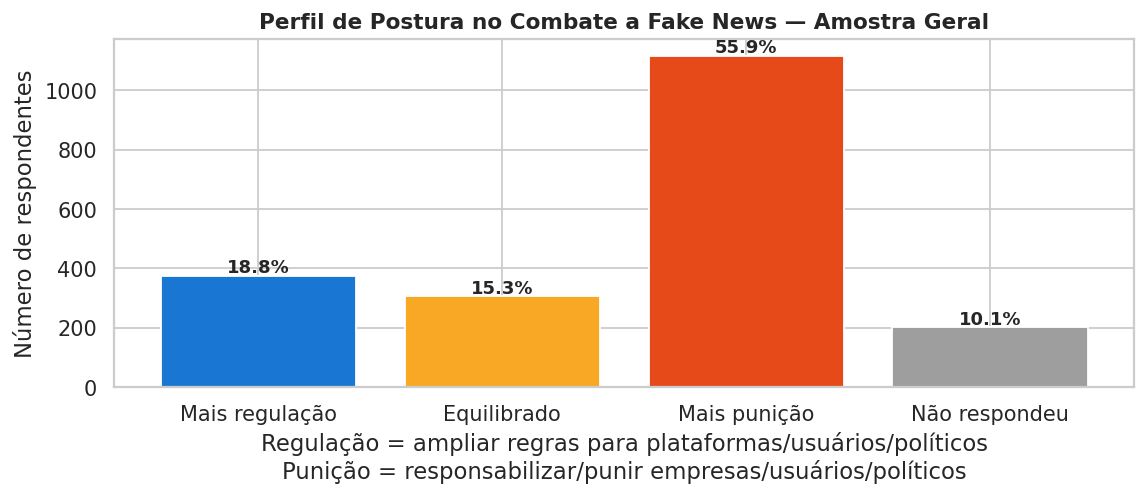

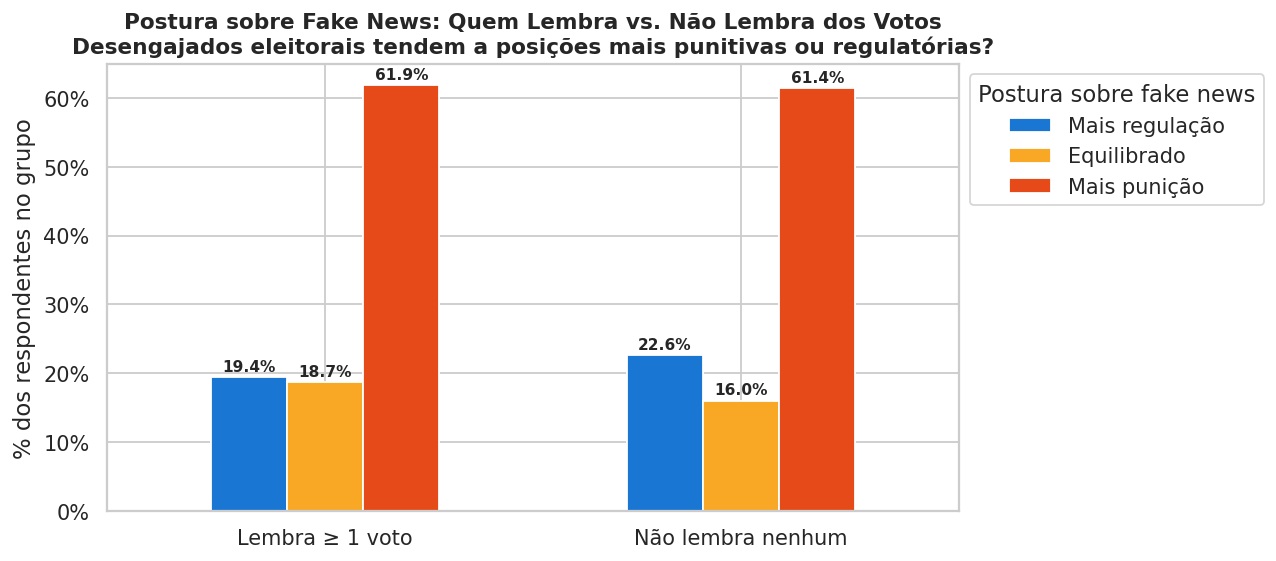

In [10]:
# @title Análise central: Desengajamento eleitoral × Postura sobre fake news

# --- Parte 1: Perfil geral de postura sobre fake news ---
ordem_perfil = ['Mais regulação', 'Equilibrado', 'Mais punição', 'Não respondeu']
cores_perfil = [COR_REG, COR_EQ, COR_PUN, '#9E9E9E']

perfil_counts = df['perfil_fn'].value_counts().reindex(ordem_perfil).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(perfil_counts.index, perfil_counts.values,
              color=cores_perfil, edgecolor='white')
for bar in bars:
    h   = bar.get_height()
    pct = h / len(df) * 100
    ax.text(bar.get_x()+bar.get_width()/2, h+10,
            f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Perfil de Postura no Combate a Fake News — Amostra Geral',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Número de respondentes')
ax.set_xlabel('Regulação = ampliar regras para plataformas/usuários/políticos\n'
              'Punição = responsabilizar/punir empresas/usuários/políticos')
plt.tight_layout()
plt.savefig('S4_perfil_geral.png', bbox_inches='tight')
plt.show()

# --- Parte 2: Perfil × Memória eleitoral (argumento central) ---
df_central = df[df['perfil_fn'] != 'Não respondeu'].copy()
df_central['memoria'] = 'Lembra ≥ 1 voto'
df_central.loc[df_central['nlembra_nenhum'], 'memoria'] = 'Não lembra nenhum'
df_central.loc[~df_central['lembra_algum'] & ~df_central['nlembra_nenhum'], 'memoria'] = 'Outros'
df_central = df_central[df_central['memoria'] != 'Outros']

cross = (df_central.groupby(['memoria','perfil_fn'])
           .size().unstack(fill_value=0))
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct = cross_pct.reindex(columns=[c for c in ordem_perfil if c in cross_pct.columns])
cross_pct = cross_pct.reindex(['Lembra ≥ 1 voto','Não lembra nenhum'])

fig, ax = plt.subplots(figsize=(10, 4.5))
cross_pct.plot(kind='bar', ax=ax,
               color=[COR_REG, COR_EQ, COR_PUN][:len(cross_pct.columns)],
               edgecolor='white', width=0.55)

for container in ax.containers:
    for patch in container.patches:
        h = patch.get_height()
        if h > 1.5:
            ax.text(patch.get_x()+patch.get_width()/2, h+0.5,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('Postura sobre Fake News: Quem Lembra vs. Não Lembra dos Votos\n'
             'Desengajados eleitorais tendem a posições mais punitivas ou regulatórias?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% dos respondentes no grupo')
ax.set_xticklabels(['Lembra ≥ 1 voto','Não lembra nenhum'], rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Postura sobre fake news', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('S4_central_memoria_x_fakenews.png', bbox_inches='tight')
plt.show()

**Leitura — o achado central.** A amostra é majoritariamente **punitivista**:

| Perfil no combate a fake news | Respondentes | % |
|---|---|---|
| Mais **punição** | 1.117 | **55,9%** |
| Mais **regulação** | 375 | 18,8% |
| Equilibrado | 307 | 15,4% |
| Não respondeu | 201 | 10,1% |

A preferência por **punir** (empresas, usuários, políticos) supera por ampla margem a por
**regular**. O cruzamento com memória eleitoral mostra que esse traço atravessa tanto
engajados quanto desengajados — a pulsão punitiva é um traço geral da opinião, não de um nicho.

## 10. Base externa — abstenção oficial do TSE (2022)

Até aqui, todos os cruzamentos foram **internos** à pesquisa. Aqui integramos uma **base pública
externa** — a **abstenção oficial do TSE no 2º turno de 2022** — para testar a
**representatividade** da amostra: o que os respondentes declaram sobre ter votado bate com o
comportamento eleitoral real de cada região?

A pesquisa só identifica a **região** (não a UF), então agregamos as taxas estaduais de
abstenção do TSE por região (média simples).

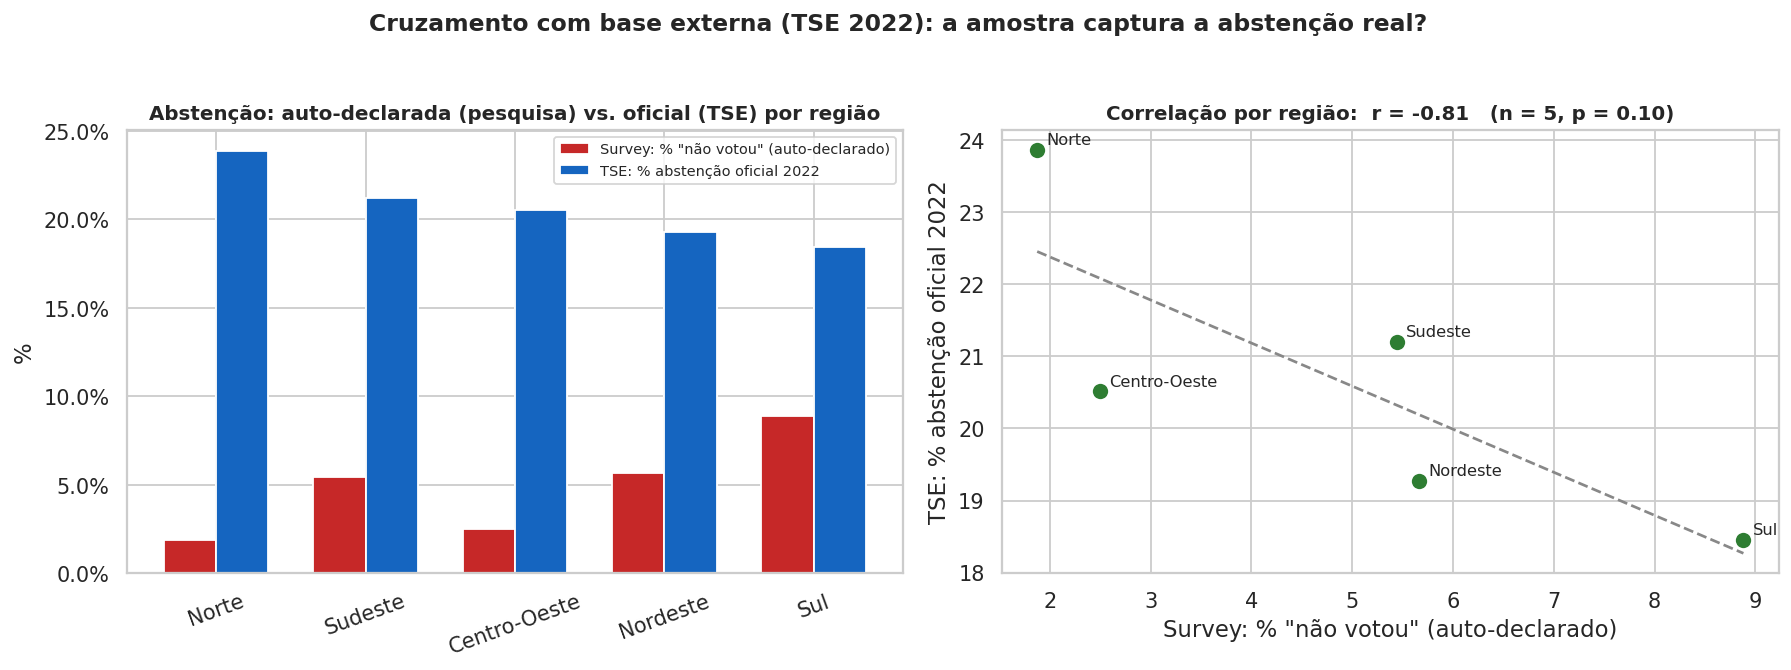

              Survey: % "não votou" (auto-declarado)  TSE: % abstenção oficial 2022
regiao                                                                             
Norte                                           1.88                          23.87
Sudeste                                         5.44                          21.20
Centro-Oeste                                    2.50                          20.52
Nordeste                                        5.66                          19.28
Sul                                             8.88                          18.45

Pearson r = -0.806  (n = 5, p = 0.099)


In [11]:
# @title Base externa — abstenção oficial do TSE (2º turno, 2022) por região
# Fonte: TSE / ranking de abstenção por UF no 2o turno de 2022 (CNN Brasil, dados TSE).
# A pesquisa traz apenas REGIAO (nao UF); agregamos as UFs por regiao (media simples das taxas).
from scipy import stats

abst_uf = {  # % de abstencao por UF — 2o turno 2022
    'AC':28.41,'AP':27.17,'RO':24.68,'PA':22.65,'RR':21.92,'AM':21.88,'TO':20.38,
    'MA':23.51,'AL':23.25,'BA':20.48,'SE':18.89,'PI':18.74,'RN':17.44,'PE':17.31,'CE':17.14,'PB':16.74,
    'RJ':22.24,'SP':21.06,'MG':20.99,'ES':20.53,
    'RS':19.31,'PR':18.63,'SC':17.42,
    'MT':22.53,'MS':22.35,'GO':20.47,'DF':16.72,
}
uf_regiao = {
    'AC':'Norte','AP':'Norte','RO':'Norte','PA':'Norte','RR':'Norte','AM':'Norte','TO':'Norte',
    'MA':'Nordeste','AL':'Nordeste','BA':'Nordeste','SE':'Nordeste','PI':'Nordeste',
    'RN':'Nordeste','PE':'Nordeste','CE':'Nordeste','PB':'Nordeste',
    'RJ':'Sudeste','SP':'Sudeste','MG':'Sudeste','ES':'Sudeste',
    'RS':'Sul','PR':'Sul','SC':'Sul',
    'MT':'Centro-Oeste','MS':'Centro-Oeste','GO':'Centro-Oeste','DF':'Centro-Oeste',
}
tse = pd.DataFrame({'uf': list(abst_uf), 'abst': list(abst_uf.values())})
tse['regiao'] = tse['uf'].map(uf_regiao)
tse_reg = tse.groupby('regiao')['abst'].mean()             # abstencao oficial media por regiao

# Lado da pesquisa: % que declara NAO ter votado em 2022 (P1A == 3), por regiao
REG_MAP = {1.0:'Norte', 2.0:'Nordeste', 3.0:'Sudeste', 4.0:'Sul', 5.0:'Centro-Oeste'}
df['regiao']    = df['REGIAO'].map(REG_MAP)
df['nao_votou'] = (df['P1A'] == 3.0)
surv_reg = df.groupby('regiao')['nao_votou'].mean() * 100

comp = pd.DataFrame({
    'Survey: % "não votou" (auto-declarado)': surv_reg,
    'TSE: % abstenção oficial 2022':          tse_reg,
}).dropna()
ordem = comp['TSE: % abstenção oficial 2022'].sort_values(ascending=False).index
comp = comp.loc[ordem]

r, p = stats.pearsonr(comp.iloc[:, 0], comp.iloc[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp.plot(kind='bar', ax=axes[0], color=['#C62828', '#1565C0'], edgecolor='white', width=0.7)
axes[0].set_title('Abstenção: auto-declarada (pesquisa) vs. oficial (TSE) por região',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('%'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(fontsize=8)

axes[1].scatter(comp.iloc[:, 0], comp.iloc[:, 1], s=90, color='#2E7D32', zorder=3, edgecolor='white')
for reg, row in comp.iterrows():
    axes[1].annotate(reg, (row.iloc[0], row.iloc[1]), fontsize=9,
                     xytext=(5, 3), textcoords='offset points')
m, b = np.polyfit(comp.iloc[:, 0], comp.iloc[:, 1], 1)
xs = np.linspace(comp.iloc[:, 0].min(), comp.iloc[:, 0].max(), 50)
axes[1].plot(xs, m * xs + b, '--', color='#888')
axes[1].set_xlabel('Survey: % "não votou" (auto-declarado)')
axes[1].set_ylabel('TSE: % abstenção oficial 2022')
axes[1].set_title(f'Correlação por região:  r = {r:+.2f}   (n = {len(comp)}, p = {p:.2f})',
                  fontsize=11, fontweight='bold')

plt.suptitle('Cruzamento com base externa (TSE 2022): a amostra captura a abstenção real?',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('A_base_externa_TSE.png', bbox_inches='tight')
plt.show()

print(comp.round(2).to_string())
print(f'\nPearson r = {r:+.3f}  (n = {len(comp)}, p = {p:.3f})')


**Leitura — representatividade e o limite da auto-declaração.** O confronto com o dado oficial
revela uma divergência:

- **Escala.** A abstenção *auto-declarada* na pesquisa (≈ 2%–9% por região) é muito **menor** que
  a abstenção *oficial* do TSE (≈ 18%–24%). Há forte **sub-relato**, em parte desejabilidade
  social ("dizer que votou"), em parte cobertura amostral.
- **Direção.** A correlação por região é **negativa** (r ≈ −0,8): o **Norte**, que tem a
  **maior** abstenção oficial, é onde **menos** gente declara não ter votado. Ou seja, a amostra
  tende a alcançar justamente os mais propensos a votar, **sub-representando abstencionistas**
  onde a abstenção real é mais alta.
- **Padrão por idade (TSE, qualitativo).** O voto é facultativo para **16–17 anos** e **65+**, as
  faixas de maior abstenção real. Coerentemente, na pesquisa a auto-declaração de "não votou"
  dispara em **16–17 (≈ 35%)**, o único ponto em que o auto-relato se aproxima do padrão oficial.

> **Cautela:** a correlação é descritiva, com **n = 5 regiões** (baixo poder).
> A leitura central — *sub-relato sistemático de abstenção* — independe do n e é um diagnóstico
> de **representatividade**, não de causalidade. Fonte da abstenção por UF: TSE, 2º turno 2022.

## 11. Conclusões

1. **Desengajamento é a marca da amostra:** 78% sem vontade de participar e ~64% sem lembrar do
   próprio voto de 2022.
2. **Memória e engajamento andam juntos:** lembrar do voto cai de ~59% (muita vontade) para ~32%
   (nenhuma vontade).
3. **Agenda material é consensual;** as divergências entre engajados e desengajados estão nas
   pautas mais abstratas/identitárias.
4. **Opinião sobre fake news é ampla e punitivista:** 55,9% pendem a *punir* vs. 18,8% a *regular*,
   independentemente do nível de engajamento.
5. **Confronto com o TSE (base externa):** a auto-declaração de voto **sub-representa a abstenção
   real** e diverge regionalmente — alerta de representatividade relevante para qualquer
   inferência a partir desta pesquisa.

**Limitações:** amostra de survey (auto-relato, desejabilidade social); cruzamento externo
limitado à granularidade regional (n=5); associações descritivas, sem inferência causal.

### Apêndice — gráficos exportados

In [12]:
## Salvando gráficos

graficos = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f"\n{len(graficos)} gráfico(s) gerado(s) e salvos:")
for g in graficos:
    print(f"   {g}")



8 gráfico(s) gerado(s) e salvos:
   A_base_externa_TSE.png
   P1xP2_prioridades.png
   P1xP3_intensidade.png
   P4_distribuicao.png
   P4xP1_memoria.png
   P4xP3_fakenews.png
   S4_central_memoria_x_fakenews.png
   S4_perfil_geral.png
